#Probabilidad: Exploración de distribuciones y limpieza de datos

Fernanda Lizeth Zambrano Gudiño

In [3]:
import pandas as pd

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#Revisión inicial y limpieza

En esta sección se explorará la estructura general del dataset y se realizará una limpieza básica.



In [7]:
# Dimensiones del Data Frame
print(df.shape)


(1338, 7)


In [8]:
# Tipo de dato de cada columna
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
#Ver valores nulos
print(df.isnull().sum())


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
#Ver cuantas filas están repetidas
print(df.duplicated().sum())


1


In [21]:
#Eliminamos la fila repetida
df = df.drop_duplicates()
print(df.shape)

(1337, 8)


In [12]:
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].value_counts()) #Cuantas veces aparece cada valor

['female' 'male']
['yes' 'no']
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


El dataset contiene 1338 registros y 7 variables, sin valores faltantes en ninguna columna. Se encontró 1 fila duplicada, la cual fue eliminada, dejando el dataset con 1337 registros únicos. Las variables categóricas (sex, smoker, region) no presentan valores inconsistentes o mal escritos — cada una tiene únicamente las categorías esperadas

# Análisis de una variable numérica

En esta sección se estudiará el comportamiento de una variable numérica continua.  


13270.422265141257 12105.484975561612


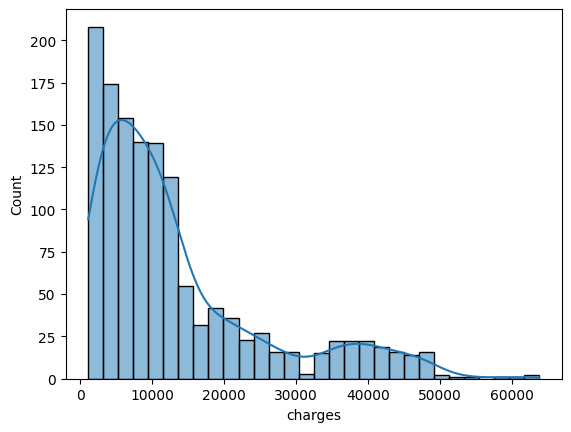

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Histograma con curva de densidad
sns.histplot(df["charges"], kde=True)

# Ajuste de distribución normal
mu, sigma = norm.fit(df["charges"]) #Escoge los dos parámetros que mejor se ajustan a una distribución normal
print(mu, sigma)

La distribución de charges no se ajusta bien a una distribución normal. Presenta un sesgo pronunciado hacia la derecha, con la mayoría de los valores concentrados en costos bajos (0-15,000), y una cola larga de valores extremos hacia la derecha. Además, se observa un segundo grupo de valores entre 35,000 y 50,000, sugiriendo que la variable podría estar compuesta por dos subpoblaciones distintas — posiblemente relacionadas con si la persona es fumadora o no. Esto se confirma con sigma ≈ 12,105, un valor de dispersión muy alto en relación a la media (13,270), reflejando la gran variabilidad de los datos

#Comparación entre categorías

En esta sección se analizará cómo varía una variable numérica cuando se agrupa por categorías.





<Axes: xlabel='smoker', ylabel='charges'>

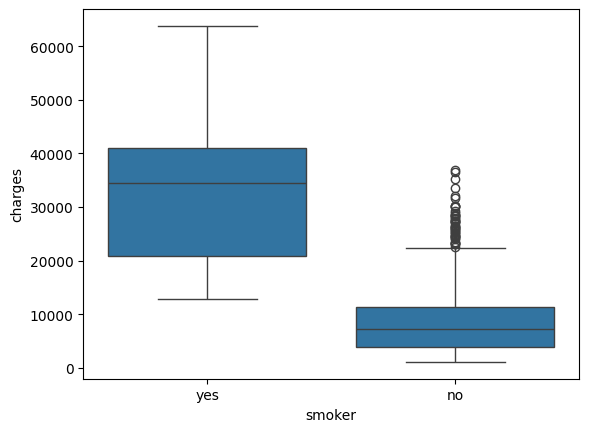

In [14]:
#boxplot
sns.boxplot(x="smoker", y="charges", data=df)

<Axes: xlabel='sex', ylabel='bmi'>

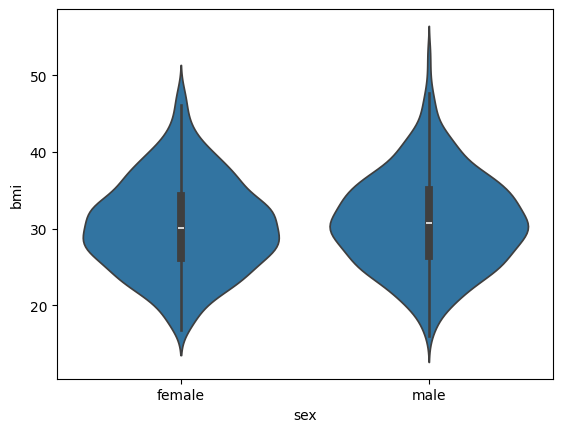

In [15]:
#Violinplot
sns.violinplot(x="sex", y="bmi", data=df)

<Axes: xlabel='region', ylabel='charges'>

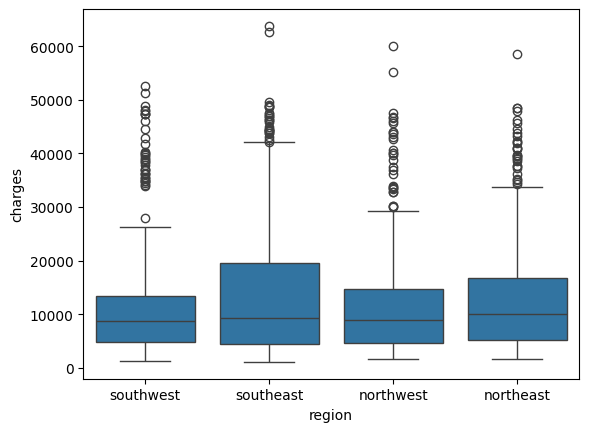

In [16]:
# Comparación por región
sns.boxplot(x="region", y="charges", data=df)

#  Resumen estadístico por grupos

En esta sección se calcularán las estadísticas descriptivas para una variable numérica, agrupando según una variable categórica




In [19]:
# Resumen por grupo
df.groupby("smoker")["charges"].describe()

# Media y desviación estándar por sexo
df.groupby("sex")["bmi"].agg(["mean", "std"])

# Mínimo y máximo por región
df.groupby("region")["charges"].agg(["min", "max"])

,min,max
region,,
northeast,1694.7964,58571.07448
northwest,1621.3402,60021.39897
southeast,1121.8739,63770.42801
southwest,1241.5650,52590.82939


# Transformaciones de variables

En esta sección se aplicarán transformaciones a una variable numérica para mejorar su comportamiento estadístico y su ajuste a distribuciones teóricas.




<Axes: xlabel='charges', ylabel='Count'>

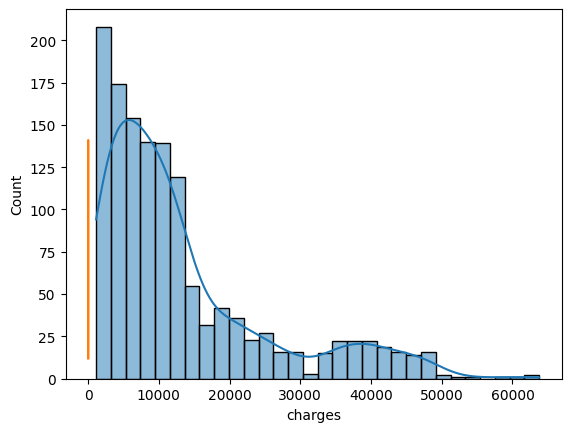

In [20]:
import numpy as np

# Histograma original
sns.histplot(df["charges"], kde=True)

# Transformación logarítmica
df["log_charges"] = np.log(df["charges"])

# Histograma transformado
sns.histplot(df["log_charges"], kde=True)

En esta actividad se trabajó con el Medical Cost Personal Dataset, aplicando conceptos de probabilidad y estadística para explorar y limpiar un conjunto de datos real. En primer lugar, se realizó una revisión inicial que confirmó que el dataset no tenía valores nulos, aunque sí se encontró una fila duplicada, la cual fue eliminada como parte del proceso de limpieza. Este paso es fundamental porque ningún análisis ni modelo de Machine Learning puede ser confiable si los datos contienen errores, inconsistencias o registros repetidos; de hecho, en la práctica profesional, la limpieza de datos suele ocupar la mayor parte del tiempo de trabajo de un científico de datos, más que el modelado en sí.

Después se analizó la distribución de la variable charges, comparándola contra una distribución normal teórica mediante el ajuste de sus parámetros (mu y sigma). Se encontró que esta variable no sigue una distribución normal: presenta un sesgo pronunciado hacia la derecha, con la mayoría de los valores concentrados en costos bajos y una cola larga de valores extremos, además de un segundo grupo de valores separado del resto, lo que sugiere la presencia de dos subpoblaciones distintas dentro de los datos, probablemente relacionadas con la condición de fumador. Este hallazgo es relevante porque muchos métodos estadísticos y algoritmos de Machine Learning asumen que las variables numéricas siguen una distribución normal; cuando esto no ocurre, es necesario aplicar transformaciones, como la logarítmica, para acercar los datos a ese comportamiento y mejorar el desempeño de los modelos que se construyan posteriormente.

Este tipo de análisis tiene aplicaciones directas en la vida real, particularmente en el sector de seguros de salud, que es precisamente el contexto del dataset utilizado. Las aseguradoras emplean este tipo de exploración estadística para fijar primas de manera justificada: si se confirma que el costo médico está fuertemente influenciado por variables como fumar, esto respalda por qué se cobra distinto a distintos perfiles de clientes, no de forma arbitraria sino con base en patrones estadísticos reales. De manera similar, estas técnicas se aplican en finanzas, donde los ingresos de las personas presentan distribuciones sesgadas parecidas, y en salud pública, donde identificar subpoblaciones dentro de una distribución ayuda a detectar grupos de riesgo que requieren atención o políticas diferenciadas.

En conjunto, esta actividad permitió practicar el flujo de trabajo que sigue cualquier científico de datos antes de construir un modelo predictivo: limpiar los datos, explorar su estructura, entender la forma de sus distribuciones y aplicar transformaciones cuando es necesario. Omitir estos pasos y pasar directamente al modelado puede llevar a construir modelos sobre datos mal entendidos, lo que compromete la validez de cualquier conclusión o predicción que se obtenga a partir de ellos.
